<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_06_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mandatory

#Problem 1: Z-Score Method (Normal Data)

Dataset (Age of students in a class):

[18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70]


Tasks:
- Calculate the mean and standard deviation of Age.
- Compute Z-Score for each value.
- Identify outliers using |Z| > 3 conditions.
- Remove those outliers and show the new dataset length.


In [14]:
df = pd.DataFrame({'Age' : [18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70]})

df

,Age
0,18
1,19
2,20
3,20
4,21
5,21
6,22
7,22
8,23
9,24


In [15]:
# Calculate the mean and standard deviation of Age.
age_mean = df['Age'].mean()
std_age = df['Age'].std()

# Compute Z-Score for each value.
df['ZScore_age'] = (df['Age'] - age_mean) / std_age

# Identify outliers using |Z| > 3 conditions.
outliers = df[abs(df['ZScore_age']) > 3]
print(len(outliers))
display(outliers)

# Remove those outliers and show the new dataset length.
df_clean = df[abs(df['ZScore_age']) <= 3]
print(f'Cleaned Dataset: {df_clean}')

1


,Age,ZScore_age
19,70,3.428778


Cleaned Dataset:     Age  ZScore_age
0    18   -0.857195
1    19   -0.774772
2    20   -0.692349
3    20   -0.692349
4    21   -0.609927
5    21   -0.609927
6    22   -0.527504
7    22   -0.527504
8    23   -0.445082
9    24   -0.362659
10   25   -0.280237
11   26   -0.197814
12   27   -0.115392
13   28   -0.032969
14   30    0.131876
15   32    0.296721
16   35    0.543989
17   40    0.956102
18   45    1.368214


# Problem 2: IQR Method (Skewed Data)

Dataset (Monthly salaries in thousand BDT):

[25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500]

Tasks:
- Calculate Q1 (25th percentile) and Q3 (75th percentile).
- Find IQR = Q3 - Q1.
- Calculate lower bound and upper bound.
- Identify outliers.
- Cap (clip) the outliers to the bounds instead of deleting them.
- Show min and max after capping.

In [16]:
df2 = pd.DataFrame({'Salaries' : [25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500]})

df2

,Salaries
0,25
1,28
2,30
3,32
4,32
5,33
6,35
7,35
8,36
9,38


In [17]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile).
Salary_Q1 = df2['Salaries'].quantile(0.25)
Salary_Q3 = df2['Salaries'].quantile(0.75)

# Find IQR = Q3 - Q1.
Salary_IQR = Salary_Q3 - Salary_Q1
print('Salary IQR:', Salary_IQR)

# Calculate lower bound and upper bound.
lower_bound = Salary_Q1 - 1.5 * Salary_IQR
upper_bound = Salary_Q3 + 1.5 * Salary_IQR
print('Lower Bound', lower_bound)
print('Upper Bound', upper_bound)

# Identify outliers.
outliers = df2[((df2['Salaries']) < lower_bound) | ((df2['Salaries']) > upper_bound)]
print(len(outliers))
print(outliers)

# Cap (clip) the outliers to the bounds instead of deleting them.
df2['Salaries'] = df2['Salaries'].clip(lower_bound, upper_bound)

# Show min and max after capping.
min = df2['Salaries'].min()
max = df2['Salaries'].max()

print('Min value', min)
print('Max value', max)

Salary IQR: 35.0
Lower Bound -17.5
Upper Bound 122.5
4
    Salaries
21       150
22       200
23       250
24       500
Min value 25.0
Max value 122.5


# Problem 3: Choose the Right Method

Dataset A (Exam scores):
[55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20]

Note: There are two very low scores (15, 20) and three high scores (100).

Dataset B (House prices in lakh BDT):
[30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200]

Tasks:
- For Dataset A, plot a histogram (conceptually) – is it normal or skewed?
- Which method (Z-Score or IQR) would you choose for Dataset A? Why?
- For Dataset B, which method would you choose? Why?
- Apply IQR on Dataset B and count how many outliers you get.


<Axes: xlabel='Score', ylabel='Count'>

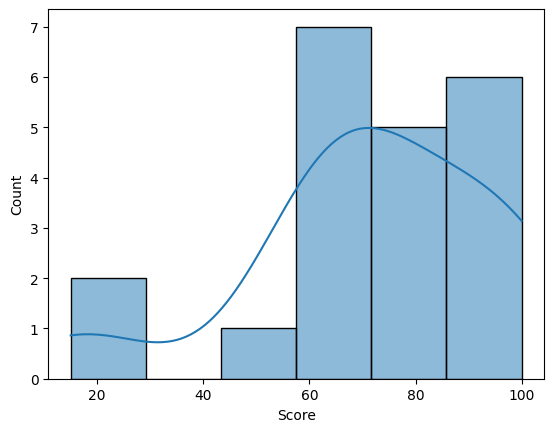

In [25]:
dataset_A = pd.DataFrame({'Score': [55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20]})

# For Dataset A, plot a histogram (conceptually) – is it normal or skewed?
sns.histplot(data = dataset_A, x = 'Score', kde=True)
# Ans: It is negatively skewed because the histogram shows the distribution in skewed in the left.

# Which method (Z-Score or IQR) would you choose for Dataset A? Why?
### Ans: I would choose IQR over Z-Score because the Z-Score can be manipulated because of outliers and it's exclusively depends on mean which can be easily manipulated by outliers but IQR doesn't affect by outliers as is uses median for calculating the quartiles and uses the Q1 and Q3 (quartiles) which can be clipped.

# For Dataset B, which method would you choose? Why?



<Axes: xlabel='Price', ylabel='Count'>

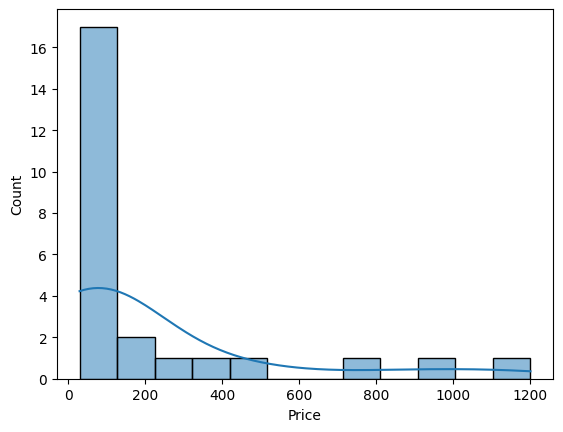

In [28]:
dataset_B = pd.DataFrame({'Price': [30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200]})

# For Dataset B, which method would you choose? Why?
sns.histplot(data = dataset_B, x = 'Price', kde=True)
# Ans: For dataset b also I would use the IQR method because dataset b is rightly skewed and IQR method can deal with the outliers easily instead of Z-Score method.

In [35]:
# Apply IQR on Dataset B and count how many outliers you get.
Price_Q1 = dataset_B['Price'].quantile(0.25)
Price_Q3 = dataset_B['Price'].quantile(0.75)

Price_IQR = Price_Q3 - Price_Q1
print('Price IQR', Price_IQR)

Price_lower_bound = Price_Q1 - 1.5 * Price_IQR
Price_upper_bound = Price_Q3 + 1.5 * Price_IQR


price_outliers = dataset_B[(dataset_B['Price'] < Price_lower_bound) | (dataset_B['Price'] > Price_upper_bound)]
print(len(price_outliers))
display(price_outliers)

Price IQR 155.0
4


,Price
21,500
22,800
23,1000
24,1200


# Problem 4: Winsorization (Percentile Method)

Dataset (Product ratings out of 10):
[1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5]

Tasks:
- Use 5% Winsorization (x = 5, meaning cap at 5th and 95th percentiles).
- Calculate 5th percentile and 95th percentile.
- Cap all values below 5th percentile to the 5th percentile value.
- Cap all values above 95th percentile to the 95th percentile value.
- Show the min and max after Winsorization.
- Explain why Winsorization is better than deletion here.



In [37]:
df3 = pd.DataFrame({'Ratings': [1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5]})

# Use 5% Winsorization (x = 5, meaning cap at 5th and 95th percentiles).
x = 5
x = x/100

# Calculate 5th percentile and 95th percentile.
min_val = df3['Ratings'].quantile(x)
max_val = df3['Ratings'].quantile(1-x)

# Cap all values below 5th percentile to the 5th percentile value.
# df3['Ratings_Winsorized'] = df3['Ratings'].clip(min_val)

# Cap all values above 95th percentile to the 95th percentile value.
# df3['Ratings_Winsorized'] = df3['Ratings'].clip(max_val)

# Cap all values below 5th percentile to the 5th percentile value.
# Cap all values above 95th percentile to the 95th percentile value.
df3['Ratings_Winsorized'] = df3['Ratings'].clip(lower=min_val, upper=max_val)

min_rate = df3['Ratings_Winsorized'].min()
max_rate = df3['Ratings_Winsorized'].max()

print(f'Min: {min_rate}, Max: {max_rate}')

Min: 1.0, Max: 10.0


# Explain why Winsorization is better than deletion here.

### Winsorization is better than deletation because it includes all the values in the dataset which might be an outlier but important for the dataset.

# Extra (Optional)



# Problem 5: Mixed Methods – Compare Z-Score & IQR on Same Data

Dataset (Product ratings out of 10):
[12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000]


Tasks:
- Plot a histogram (conceptually) and decide if the data is normal or skewed.
- Apply Z-Score method (|Z| > 3) – count outliers and list them.
- Apply IQR method (1.5×IQR) – count outliers and list them.
- Which method found more outliers? Why?
- Which method would you trust here? Justify.


<Axes: xlabel='Product', ylabel='Count'>

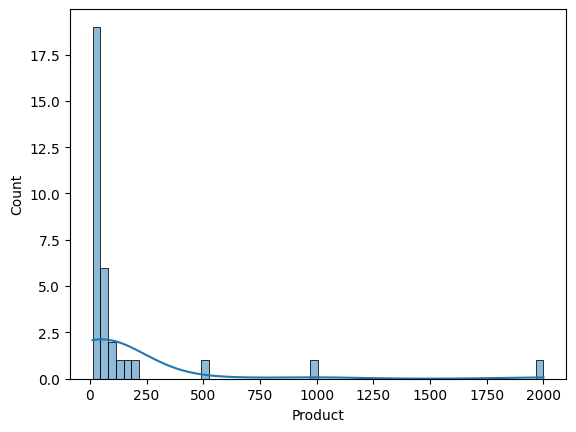

In [39]:
df4 = pd.DataFrame({'Product' : [12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000]})

# Plot a histogram (conceptually) and decide if the data is normal or skewed.
sns.histplot(data = df4, x = 'Product', kde = True)

#Ans: It is positively skewed

In [40]:
# Apply Z-Score method (|Z| > 3) – count outliers and list them.
product_mean = df4['Product'].mean()
product_std = df4['Product'].std()

df4['ZScore_Product'] = (df4['Product'] - product_mean) / product_std

product_outliers = df4[abs(df4['ZScore_Product']) > 3]
print(len(product_outliers))
display(product_outliers)

1


,Product,ZScore_Product
32,2000,4.865011


In [43]:
# Apply IQR method (1.5×IQR) – count outliers and list them.
product_Q1 = df4['Product'].quantile(0.25)
product_Q3 = df4['Product'].quantile(0.75)

product_IQR = product_Q3 - product_Q1

product_low = product_Q1 - 1.5 * product_IQR
product_up = product_Q3 + 1.5 * product_IQR

prod_outlier = df4[(df4['Product'] < product_low) | (df4['Product'] > product_up)]
print(len(prod_outlier))
display(prod_outlier)

4


,Product,ZScore_Product
29,200,0.123954
30,500,0.914130
31,1000,2.231090
32,2000,4.865011


# Which method found more outliers? Why?

Ans: IQR found more outliers. Because the data is heavily right-skewed, extreme values (500, 1000, 2000) inflate the mean and std, compressing. Z-scores and masking outliers. IQR uses Q1 & Q3 which are unaffected by extreme values, so it detects more outliers accurately.

# Which method would you trust here? Justify.

IQR is more trustworthy here. Since the data is skewed, Z-Score is unreliable — outliers distort the mean and std it depends on. IQR relies on Q1 and Q3 (quartiles), making it robust to skewed distributions and extreme values.

# Problem 6: Real-World Scenario – Employee Bonus

Scenario:
A company gives an annual bonus (in thousand BDT). HR wants to remove extreme outliers before calculating average bonus for policy making.


Dataset (Bonus amounts):
[5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300]

Tasks:
- Calculate mean, median, and mode. What do you observe?
- Apply IQR method and find outliers.
- Instead of deleting, apply Winsorization with x = 3 (i.e., cap at 3rd and 97th percentile).
- Show the new min and max after Winsorization.
- Calculate the new mean after Winsorization. Is it more reasonable than the original mean?



In [49]:
df5 = pd.DataFrame({'Bonus' :  [5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300]})

# Calculate mean, median, and mode. What do you observe?
bonus_mean   = df5['Bonus'].mean()
bonus_median = df5['Bonus'].median()
bonus_mode   = df5['Bonus'].mode()[0]
print(f'Mean: {bonus_mean:.2f}, Median: {bonus_median}, Mode: {bonus_mode}')
# Obs: Mean >> Median >> Mode — data is right-skewed;
# extreme bonuses (150, 200, 300) pull the mean up significantly.

Mean: 42.24, Median: 12.0, Mode: 7


In [48]:
# Apply IQR method and find outliers.
bonus_Q1  = df5['Bonus'].quantile(0.25)
bonus_Q3  = df5['Bonus'].quantile(0.75)

bonus_IQR = bonus_Q3 - bonus_Q1

bonus_low = bonus_Q1 - 1.5 * bonus_IQR
bonus_up  = bonus_Q3 + 1.5 * bonus_IQR

bonus_outliers = df5[(df5['Bonus'] < bonus_low) | (df5['Bonus'] > bonus_up)]
print(f'Number of Outliers: {len(bonus_outliers)}')
display(bonus_outliers)

Number of Outliers: 5


,Bonus
28,100
29,120
30,150
31,200
32,300


In [50]:
# Instead of deleting, apply Winsorization with x = 3 (i.e., cap at 3rd and 97th percentile).
x = 3
x = x / 100
win_min = df5['Bonus'].quantile(x)
win_max = df5['Bonus'].quantile(1 - x)

df5['Bonus_Winsorized'] = df5['Bonus'].clip(lower=win_min, upper=win_max)

/tmp/ipykernel_10882/807121371.py:7: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df5['Bonus_Winsorized'] = df5['Bonus'].clip(lower=win_min, upper=win_max)


In [51]:
# Show the new min and max after Winsorization.
print(f'Min after Winsorization: {df5["Bonus_Winsorized"].min()}')
print(f'Max after Winsorization: {df5["Bonus_Winsorized"].max()}')

Min after Winsorization: 5
Max after Winsorization: 204


In [53]:
# Calculate the new mean after Winsorization. Is it more reasonable than the original mean?
new_mean = df5['Bonus_Winsorized'].mean()
print(f'Original Mean: {bonus_mean:.2f}')
print(f'New Mean:      {new_mean:.2f}')
# Ans: Yes — the new mean is more reasonable. The original mean was heavily inflated by extreme bonuses (200, 300). After Winsorization, the mean better reflects the typical employee bonus.

Original Mean: 42.24
New Mean:      39.33
